Working with strings

In [20]:
import numpy as np
import pandas as pd
import re

In [2]:
arr1 = np.array([2,3,5,7,8,9])
arr1

array([2, 3, 5, 7, 8, 9])

In [10]:
arr1 ** arr1
# OR
np.square(arr1)

array([ 4,  9, 25, 49, 64, 81])

In [14]:
students =  ['Eno','Carl','VICTOR','Nigel',None,'Byron','Christine']
[student.capitalize() for student in students ]

AttributeError: 'NoneType' object has no attribute 'capitalize'

In [15]:
names = pd.Series(students)
names

0          Eno
1         Carl
2       VICTOR
3        Nigel
4          NaN
5        Byron
6    Christine
dtype: str

In [16]:
names.str.capitalize()

0          Eno
1         Carl
2       Victor
3        Nigel
4          NaN
5        Byron
6    Christine
dtype: str

In [17]:
names.str.startswith('V')

0    False
1    False
2     True
3    False
4    False
5    False
6    False
dtype: bool

In [19]:
students = ['Eno Bassey','Carl Musia','VICTOR Ouma','NIgek Mirambo',None,'Byron Morara','Christine Kerubo']
names = pd.Series(students)
names

0          Eno Bassey
1          Carl Musia
2         VICTOR Ouma
3       NIgek Mirambo
4                 NaN
5        Byron Morara
6    Christine Kerubo
dtype: str

In [18]:
names

0          Eno
1         Carl
2       VICTOR
3        Nigel
4          NaN
5        Byron
6    Christine
dtype: str

In [29]:
pattern = r'(\w+)'
names.str.extract(pattern)


,0
0,Eno
1,Carl
2,VICTOR
3,NIgek
4,NaN
5,Byron
6,Christine


In [30]:
names

0          Eno Bassey
1          Carl Musia
2         VICTOR Ouma
3       NIgek Mirambo
4                 NaN
5        Byron Morara
6    Christine Kerubo
dtype: str

In [ ]:
names.str.slice(0,4)

0    Eno B
1    Carl 
2    VICTO
3    NIgek
4      NaN
5    Byron
6    Chris
dtype: str

In [41]:
names[0:4]

0       Eno Bassey
1       Carl Musia
2      VICTOR Ouma
3    NIgek Mirambo
dtype: str

In [51]:
names.str.split().str.get(0)

0          Eno
1         Carl
2       VICTOR
3        NIgek
4          NaN
5        Byron
6    Christine
dtype: object

In [52]:
df = pd.DataFrame({'name':students, 'info':['E|B','C|M','V|O','N|M',None,'B|M','C|K']})
df

,name,info
0,Eno Bassey,E|B
1,Carl Musia,C|M
2,VICTOR Ouma,V|O
3,NIgek Mirambo,N|M
4,NaN,NaN
5,Byron Morara,B|M
6,Christine Kerubo,C|K


In [53]:
df['info'].str.get_dummies('|')

,B,C,E,K,M,N,O,V
0,1,0,1,0,0,0,0,0
1,0,1,0,0,1,0,0,0
2,0,0,0,0,0,0,1,1
3,0,0,0,0,1,1,0,0
4,0,0,0,0,0,0,0,0
5,1,0,0,0,1,0,0,0
6,0,1,0,1,0,0,0,0


Working with time series

In [54]:
from datetime import datetime
datetime.now()

datetime.datetime(2026, 3, 31, 13, 13, 35, 700723)

In [57]:
data = datetime(year = 2020,month = 5,day = 17)

In [59]:
type(data)

datetime.datetime

In [60]:
from dateutil import parser
date = parser.parse('2020-05-17')
date

datetime.datetime(2020, 5, 17, 0, 0)

In [61]:
date = parser.parse('4th of July, 2015')
date

datetime.datetime(2015, 7, 4, 0, 0)

In [ ]:
date.strftime('%A')

'Saturday'

In [64]:
date = np.array(['2018-04-12'],dtype = np.datetime64)
date

array(['2018-04-12'], dtype='datetime64[D]')

In [ ]:
date = np.arange(12)

In [66]:
np.datetime64('2026-01-01 12:59:33')

np.datetime64('2026-01-01T12:59:33')

In [67]:
date = pd.to_datetime("4th of July 2018")
date

Timestamp('2018-07-04 00:00:00')

In [68]:
date.strftime('%A')

'Wednesday'

In [79]:
date + pd.to_timedelta(np.arange(12),'h')

DatetimeIndex(['2018-07-04 00:00:00', '2018-07-04 01:00:00',
               '2018-07-04 02:00:00', '2018-07-04 03:00:00',
               '2018-07-04 04:00:00', '2018-07-04 05:00:00',
               '2018-07-04 06:00:00', '2018-07-04 07:00:00',
               '2018-07-04 08:00:00', '2018-07-04 09:00:00',
               '2018-07-04 10:00:00', '2018-07-04 11:00:00'],
              dtype='datetime64[us]', freq=None)

In [89]:
import yfinance as yf
sp500 = yf.download('^GSPC',start='2018-07-03',end = '2022-07-10')
sp500

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2018-07-03,2713.219971,2736.580078,2711.159912,2733.270020,1911460000
2018-07-05,2736.610107,2737.830078,2716.020020,2724.189941,2980160000
2018-07-06,2759.820068,2764.409912,2733.520020,2737.679932,2590250000
2018-07-09,2784.169922,2784.649902,2770.729980,2775.620117,3070060000
2018-07-10,2793.840088,2795.580078,2786.239990,2788.560059,3080140000
...,...,...,...,...,...
2022-07-01,3825.330078,3829.820068,3752.100098,3781.000000,4046950000
2022-07-05,3831.389893,3832.189941,3742.060059,3792.610107,5076590000


In [90]:
sp500 = sp500['Close']
sp500

Ticker,^GSPC
Date,
2018-07-03,2713.219971
2018-07-05,2736.610107
2018-07-06,2759.820068
2018-07-09,2784.169922
2018-07-10,2793.840088
...,...
2022-07-01,3825.330078
2022-07-05,3831.389893
2022-07-06,3845.080078


<Axes: xlabel='Date'>

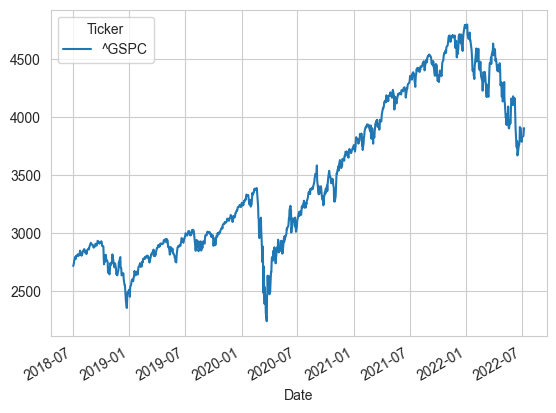

In [91]:
import seaborn as sns
sns.set_style('whitegrid')
sp500.plot()
